# Stanford Dogs 数据预处理（提前读入内存）

参照 `recruite_requirement/Cat_Dog_Classification.ipynb` 的做法：

- 不预先 Normalize，先转成 **uint8 (0~255)** 存盘，省内存
- 全部图片一次性读进一个大 tensor，存成 `.pt`
- 用 `TensorDataset` + `random_split` 划分训练/验证集
- `DataLoader` **不需要 `num_workers`**（数据已在内存）
- 训练时再在线做归一化：`.float().div(127.5).sub(1)` → 映射到 **-1~1**

数据集：`Kaggle/data/images/Images/<品种>/*.jpg`（120 个犬种，20,580 张）

In [1]:
import os, time, json
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from torchvision import datasets, transforms
from PIL import Image
import matplotlib.pyplot as plt

# matplotlib 中文字体（Windows）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('当前设备:', device)
print('PyTorch:', torch.__version__)

# ---------- 路径与参数 ----------
BASE     = r'C:\Users\moneyforever\Desktop\Deep-Learning\Kaggle\data'
ROOT     = os.path.join(BASE, 'images', 'Images')     # ImageFolder 根目录（每个子目录=一个品种）
PT_PATH  = os.path.join(BASE, 'stanford_dogs_64.pt') # 预处理结果
IMG_SIZE = 64

assert os.path.isdir(ROOT), '找不到图片目录: ' + ROOT
print('图片根目录:', ROOT)
print('输出文件  :', PT_PATH)

当前设备: cuda
PyTorch: 2.11.0+cu128
图片根目录: C:\Users\moneyforever\Desktop\Deep-Learning\Kaggle\data\images\Images
输出文件  : C:\Users\moneyforever\Desktop\Deep-Learning\Kaggle\data\stanford_dogs_64.pt


## 1. 校验图片文件（剔除损坏文件）

`ImageFolder` 遇到损坏图片会直接抛异常中断整个流程，所以先扫一遍过滤掉。

In [2]:
def is_valid_image(path):
    """能正常打开并读取头部信息才算有效"""
    try:
        with Image.open(path) as im:
            im.verify()
        return True
    except Exception:
        return False

t0 = time.time()
ds_probe = datasets.ImageFolder(root=ROOT, is_valid_file=is_valid_image)
classes = ds_probe.classes
print('有效图片: %d 张' % len(ds_probe))
print('类别数  : %d' % len(classes))
print('类别示例:', classes[:5], '...')
print('扫描耗时: %.1f 秒' % (time.time() - t0))

有效图片: 20580 张
类别数  : 120
类别示例: ['n02085620-Chihuahua', 'n02085782-Japanese_spaniel', 'n02085936-Maltese_dog', 'n02086079-Pekinese', 'n02086240-Shih-Tzu'] ...
扫描耗时: 8.5 秒


## 2. 提前读入内存

Resize → ToTensor（得到 0~1 的 float）→ **×255 转 uint8**（省 4 倍内存）→ 拼接成一个大 tensor → 存 `.pt`。

> 注意：`ImageFolder` 默认用 `pil_loader`，会把灰度图 `convert('RGB')`，所以通道数一定是 3。

In [3]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),                      # PIL -> float32, 范围 0~1
])

ds = datasets.ImageFolder(root=ROOT, transform=transform, is_valid_file=is_valid_image)
print('待处理: %d 张' % len(ds))

xs, ys = [], []
t0 = time.time()
loader = DataLoader(ds, batch_size=256, shuffle=False, num_workers=0)

for i, (X, y) in enumerate(loader):
    xs.append((X * 255).to(torch.uint8))        # float 0~1  ->  uint8 0~255
    ys.append(y)
    if (i + 1) % 20 == 0:
        done = min((i + 1) * 256, len(ds))
        print('  %5d / %d  (%.1f 秒)' % (done, len(ds), time.time() - t0), flush=True)

X8 = torch.cat(xs)      # (N, 3, 64, 64) uint8
Y  = torch.cat(ys)      # (N,) int64
print()
print('X dtype/shape:', X8.dtype, tuple(X8.shape))
print('Y dtype/shape:', Y.dtype, tuple(Y.shape))
print('内存占用: %.1f MB' % (X8.numel() * X8.element_size() / 1024 / 1024))

torch.save({'X': X8, 'Y': Y, 'classes': classes}, PT_PATH)
print('已保存 ->', PT_PATH, '(%.1f MB)' % (os.path.getsize(PT_PATH) / 1024 / 1024))
print('总耗时: %.1f 秒' % (time.time() - t0))

待处理: 20580 张
   5120 / 20580  (13.2 秒)
  10240 / 20580  (25.5 秒)
  15360 / 20580  (38.9 秒)
  20480 / 20580  (51.9 秒)

X dtype/shape: torch.uint8 (20580, 3, 64, 64)
Y dtype/shape: torch.int64 (20580,)
内存占用: 241.2 MB
已保存 -> C:\Users\moneyforever\Desktop\Deep-Learning\Kaggle\data\stanford_dogs_64.pt (241.3 MB)
总耗时: 52.5 秒


## 3. 加载并划分数据集

和参考实现一致：`TensorDataset` + `random_split`，`DataLoader` 不设 `num_workers`。

In [4]:
d = torch.load(PT_PATH, weights_only=False)
full_ds = TensorDataset(d['X'], d['Y'])
classes = d['classes']

n = len(full_ds)
n_train = int(0.8 * n)
n_val = n - n_train
train_ds, val_ds = random_split(full_ds, [n_train, n_val])

BATCH = 128
train_iter = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0)
val_iter   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0)

print('总样本: %d  |  训练: %d  |  验证: %d' % (n, n_train, n_val))
print('类别数: %d' % len(classes))
print('batch size:', BATCH)

总样本: 20580  |  训练: 16464  |  验证: 4116
类别数: 120
batch size: 128


## 4. 验证：取一个 batch 检查形状与归一化

训练循环里在线归一化（**不要**在预处理阶段做）：

```python
X = X.to(device).float().div(127.5).sub(1)   # 0~255 -> -1~1
```

In [5]:
Xb, yb = next(iter(train_iter))
print('原始 batch  :', Xb.dtype, tuple(Xb.shape), '范围', int(Xb.min()), '~', int(Xb.max()))

Xf = Xb.to(device).float().div(127.5).sub(1)
print('归一化后    :', Xf.dtype, tuple(Xf.shape), '范围 %.2f ~ %.2f' % (Xf.min().item(), Xf.max().item()))
print('标签样例    :', yb[:8].tolist(), '->', [classes[i] for i in yb[:8].tolist()])

原始 batch  : torch.uint8 (128, 3, 64, 64) 范围 0 ~ 255


归一化后    : torch.float32 (128, 3, 64, 64) 范围 -1.00 ~ 1.00
标签样例    : [60, 67, 76, 57, 52, 3, 102, 98] -> ['n02100583-vizsla', 'n02102177-Welsh_springer_spaniel', 'n02105412-kelpie', 'n02099712-Labrador_retriever', 'n02098286-West_Highland_white_terrier', 'n02086079-Pekinese', 'n02110958-pug', 'n02110063-malamute']


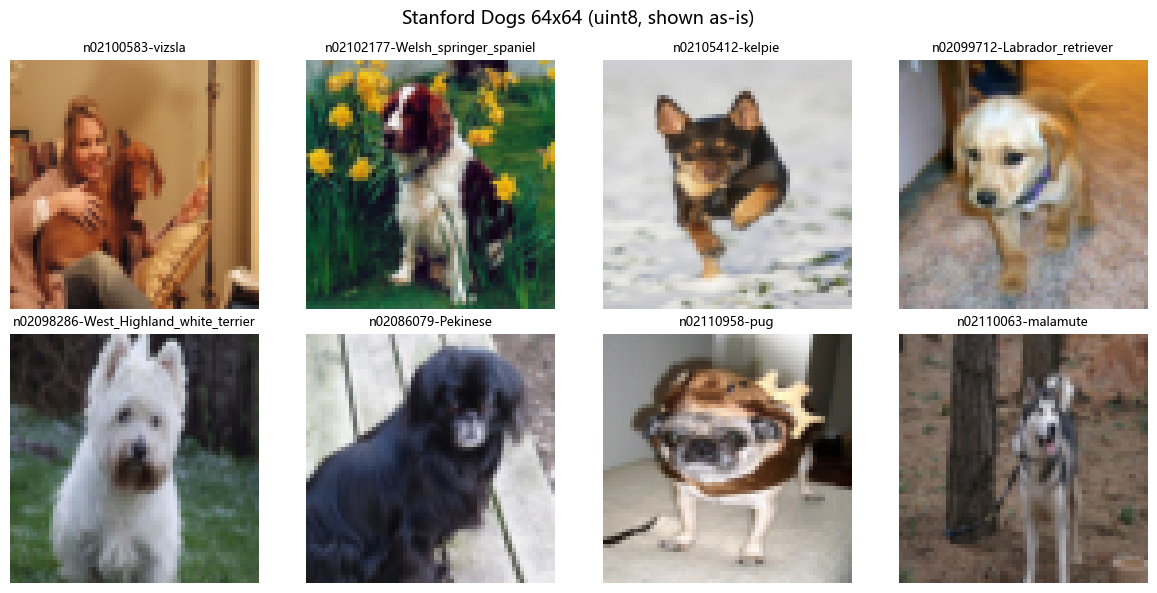

In [6]:
# 可视化 8 张样本
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, idx in zip(axes.ravel(), range(8)):
    img = Xb[idx].permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(classes[yb[idx].item()], fontsize=9)
    ax.axis('off')
plt.suptitle('Stanford Dogs 64x64 (uint8, shown as-is)', fontsize=13)
plt.tight_layout()
plt.show()

In [7]:
# 类别分布（确认是否均衡）
import collections
cnt = collections.Counter(Y.tolist())
vals = list(cnt.values())
print('每类图片数: 最少 %d, 最多 %d, 平均 %.1f' % (min(vals), max(vals), sum(vals)/len(vals)))
print('类别总数:', len(cnt))

每类图片数: 最少 148, 最多 252, 平均 171.5
类别总数: 120
